# 01 — Data Preparation and Feature Engineering

**Team DREAMS | SIADS 699 Capstone**

This notebook creates the analysis-ready NHANES dataset used by the EDA, statistical-analysis, and sensitivity-analysis notebooks.

### Planned analysis structure
- **Outcome:** PHQ-9 depressive-symptom score
- **Primary exposure:** social jetlag
- **Primary biomarker:** log-transformed hs-CRP
- **Sensitivity biomarker:** HbA1c
- **Primary interaction:** social jetlag × log(hs-CRP)
- **Covariates:** sleep duration, age, sex, race/ethnicity, income, physical activity, and smoking
- **Survey design:** NHANES examination weight, strata, and PSU

### Outputs
- Raw merged dataframe
- Cleaned dataframe with derived variables and quality flags
- Primary-model complete-case dataset
- HbA1c sensitivity-model complete-case dataset
- Sample-loss summary


In [1]:
# ------------------------------------------------------------
# ENVIRONMENT AND PATH SETUP
# Works in either Google Colab or VS Lab
# ------------------------------------------------------------

from pathlib import Path

try:
    # Google Colab setup
    from google.colab import drive

    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive")
    DATA_ROOT = PROJECT_ROOT / "capstone_data"

    PROCESSED_DIR = PROJECT_ROOT / "capstone_outputs" / "processed"
    TABLE_DIR = PROJECT_ROOT / "capstone_outputs" / "tables"

    ENVIRONMENT = "Google Colab"

except ImportError:
    # VS Lab setup
    CURRENT_DIR = Path.cwd()
    PROJECT_ROOT = None
    DATA_ROOT = None

    # Search the current directory and its parent directories
    for folder in [CURRENT_DIR, *CURRENT_DIR.parents]:
        if (folder / "capstone_data").is_dir():
            PROJECT_ROOT = folder
            DATA_ROOT = folder / "capstone_data"
            break

        if (folder / "data").is_dir():
            PROJECT_ROOT = folder
            DATA_ROOT = folder / "data"
            break

    if DATA_ROOT is None:
        raise FileNotFoundError(
            "The NHANES data folder could not be located.\n"
            "Place the source-data folders in either:\n"
            "  - capstone_data/\n"
            "  - data/\n"
            "Then run this notebook again."
        )

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
    TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

    ENVIRONMENT = "VS Lab"

# Verify the input folder before continuing.
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f"NHANES data folder not found: {DATA_ROOT}"
    )

# Create output folders if needed.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Confirm the environment and paths being used.
print("Environment:", ENVIRONMENT)
print("Project root:", PROJECT_ROOT)
print("NHANES data folder:", DATA_ROOT)
print("Processed-data folder:", PROCESSED_DIR)
print("Output-tables folder:", TABLE_DIR)

print("\nFolders found in the NHANES data directory:")

for item in sorted(DATA_ROOT.iterdir()):
    if item.is_dir():
        print("-", item.name)

Mounted at /content/drive
Environment: Google Colab
Project root: /content/drive/MyDrive
NHANES data folder: /content/drive/MyDrive/capstone_data
Processed-data folder: /content/drive/MyDrive/capstone_outputs/processed
Output-tables folder: /content/drive/MyDrive/capstone_outputs/tables

Folders found in the NHANES data directory:
- Demographic
- Dietary
- Examination
- Lab
- Questionnaire


## 1. Imports and project paths

Keep the raw NHANES files in a local `data/raw/` folder.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# Find all usable data files inside capstone_data
data_files = sorted(
    [
        path
        for path in DATA_ROOT.rglob("*")
        if path.is_file()
        and path.suffix.lower() in {".xpt", ".xport", ".csv", ".sas7bdat"}
    ],
    key=lambda path: str(path).lower()
)

print(f"Found {len(data_files)} data files:\n")

for path in data_files:
    print(path.relative_to(DATA_ROOT))


Found 113 data files:

Demographic/P_DEMO.xpt
Dietary/DSBI.xpt
Dietary/DSII.xpt
Dietary/DSPI.xpt
Dietary/P_DR1IFF.xpt
Dietary/P_DR1TOT.xpt
Dietary/P_DR2IFF.xpt
Dietary/P_DR2TOT.xpt
Dietary/P_DRXFCD.xpt
Dietary/P_DS1IDS.xpt
Dietary/P_DS1TOT.xpt
Dietary/P_DS2IDS.xpt
Dietary/P_DS2TOT.xpt
Dietary/P_DSQIDS.xpt
Dietary/P_DSQTOT.xpt
Examination/P_AUX.xpt
Examination/P_AUXAR.xpt
Examination/P_AUXTYM.xpt
Examination/P_AUXWBR.xpt
Examination/P_BMX.xpt
Examination/P_BPXO.xpt
Examination/P_DXXFEM.xpt
Examination/P_DXXSPN.xpt
Examination/P_LUX.xpt
Examination/P_OHXDEN.xpt
Examination/P_OHXREF.xpt
Lab/P_ALB_CR.xpt
Lab/P_BIOPRO.xpt
Lab/P_CBC.xpt
Lab/P_CMV.xpt
Lab/P_COT.xpt
Lab/P_CRCO.xpt
Lab/P_ETHOX.xpt
Lab/P_FASTQX.xpt
Lab/P_FERTIN.xpt
Lab/P_FETIB.xpt
Lab/P_FOLATE.xpt
Lab/P_FOLFMS.xpt
Lab/P_FR.xpt
Lab/P_GHB.xpt
Lab/P_GLU.xpt
Lab/P_HDL.xpt
Lab/P_HEPA.xpt
Lab/P_HEPB_S.xpt
Lab/P_HEPBD.xpt
Lab/P_HEPC.xpt
Lab/P_HEPE.xpt
Lab/P_HSCRP.xpt
Lab/P_IHGEM.xpt
Lab/P_INS.xpt
Lab/P_OPD.xpt
Lab/P_PBCD.xpt
Lab/P_PERN

In [3]:
EXPECTED_FILES = {
    "Demographics": ["P_DEMO", "DEMO"],
    "Depression / PHQ-9": ["P_DPQ", "DPQ"],
    "Sleep": ["P_SLQ", "SLQ"],
    "HbA1c": ["P_GHB", "GHB"],
    "hs-CRP": ["P_HSCRP", "HSCRP", "CRP"],
    "Body measures": ["P_BMX", "BMX"],
    "Physical activity": ["P_PAQ", "PAQ"],
    "Smoking": ["P_SMQ", "SMQ"],
}

file_candidates = {}

for description, search_terms in EXPECTED_FILES.items():
    matches = [
        path
        for path in data_files
        if any(term.upper() in path.stem.upper() for term in search_terms)
    ]

    file_candidates[description] = matches

    print(f"\n{description}:")
    if matches:
        for match in matches:
            print("  ", match.relative_to(DATA_ROOT))
    else:
        print("   NOT FOUND")


Demographics:
   Demographic/P_DEMO.xpt

Depression / PHQ-9:
   Questionnaire/P_DPQ.xpt

Sleep:
   Questionnaire/P_SLQ.xpt

HbA1c:
   Lab/P_GHB.xpt

hs-CRP:
   Lab/P_HSCRP.xpt

Body measures:
   Examination/P_BMX.xpt

Physical activity:
   Questionnaire/P_PAQ.xpt
   Questionnaire/P_PAQY.xpt

Smoking:
   Questionnaire/P_SMQ.xpt
   Questionnaire/P_SMQFAM.xpt
   Questionnaire/P_SMQRTU.xpt
   Questionnaire/P_SMQSHS.xpt


## 2. File configuration

The notebook expects one file for each component:
- Demographics
- Depression questionnaire
- Sleep questionnaire
- HbA1c laboratory results
- hs-CRP laboratory results
- Body measures
- Physical activity
- Smoking


In [4]:
FILE_MAP = {
    "demographics": DATA_ROOT / "Demographic" / "P_DEMO.xpt",
    "depression": DATA_ROOT / "Questionnaire" / "P_DPQ.xpt",
    "sleep": DATA_ROOT / "Questionnaire" / "P_SLQ.xpt",
    "hba1c": DATA_ROOT / "Lab" / "P_GHB.xpt",
    "crp": DATA_ROOT / "Lab" / "P_HSCRP.xpt",
    "body_measures": DATA_ROOT / "Examination" / "P_BMX.xpt",
    "physical_activity": DATA_ROOT / "Questionnaire" / "P_PAQ.xpt",
    "smoking": DATA_ROOT / "Questionnaire" / "P_SMQ.xpt",
    "occupation": (
    DATA_ROOT
    / "Questionnaire"
    / "P_OCQ.xpt"
),
}

for name, path in FILE_MAP.items():
    print(f"{name:20s} exists={path.exists()} | {path}")


demographics         exists=True | /content/drive/MyDrive/capstone_data/Demographic/P_DEMO.xpt
depression           exists=True | /content/drive/MyDrive/capstone_data/Questionnaire/P_DPQ.xpt
sleep                exists=True | /content/drive/MyDrive/capstone_data/Questionnaire/P_SLQ.xpt
hba1c                exists=True | /content/drive/MyDrive/capstone_data/Lab/P_GHB.xpt
crp                  exists=True | /content/drive/MyDrive/capstone_data/Lab/P_HSCRP.xpt
body_measures        exists=True | /content/drive/MyDrive/capstone_data/Examination/P_BMX.xpt
physical_activity    exists=True | /content/drive/MyDrive/capstone_data/Questionnaire/P_PAQ.xpt
smoking              exists=True | /content/drive/MyDrive/capstone_data/Questionnaire/P_SMQ.xpt
occupation           exists=True | /content/drive/MyDrive/capstone_data/Questionnaire/P_OCQ.xpt


## 3. Reusable helper functions


In [5]:
def load_nhanes_file(path):
    df = pd.read_sas(
        path,
        format="xport",
        encoding="utf-8"
    )

    df.columns = [
        str(column).upper().strip()
        for column in df.columns
    ]

    if "SEQN" not in df.columns:
        raise KeyError(f"{path.name} does not contain SEQN.")

    return df


demo = load_nhanes_file(FILE_MAP["demographics"])
dpq = load_nhanes_file(FILE_MAP["depression"])
sleep = load_nhanes_file(FILE_MAP["sleep"])
hba1c = load_nhanes_file(FILE_MAP["hba1c"])
crp = load_nhanes_file(FILE_MAP["crp"])
bmx = load_nhanes_file(FILE_MAP["body_measures"])
paq = load_nhanes_file(FILE_MAP["physical_activity"])
smq = load_nhanes_file(FILE_MAP["smoking"])
ocq = load_nhanes_file(FILE_MAP["occupation"]
)

source_dataframes = {
    "demographics": demo,
    "depression": dpq,
    "sleep": sleep,
    "hba1c": hba1c,
    "crp": crp,
    "body_measures": bmx,
    "physical_activity": paq,
    "smoking": smq,
    "occupation": ocq,
}

load_summary = pd.DataFrame([
    {
        "source": name,
        "rows": len(df),
        "columns": len(df.columns),
        "unique_seqn": df["SEQN"].nunique(),
        "duplicate_seqn": df["SEQN"].duplicated().sum(),
    }
    for name, df in source_dataframes.items()
])

display(load_summary)

print("\nPASS: All eight files loaded.")


,source,rows,columns,unique_seqn,duplicate_seqn
0,demographics,15560,29,15560,0
1,depression,8965,11,8965,0
2,sleep,10195,11,10195,0
3,hba1c,10409,2,10409,0
4,crp,13772,3,13772,0
5,body_measures,14300,22,14300,0
6,physical_activity,9693,17,9693,0
7,smoking,11137,16,11137,0
8,occupation,10195,6,10195,0



PASS: All eight files loaded.


## 4. Load the source files



In [6]:
 demo = load_nhanes_file(FILE_MAP["demographics"])
 dpq = load_nhanes_file(FILE_MAP["depression"])
 sleep = load_nhanes_file(FILE_MAP["sleep"])
 hba1c = load_nhanes_file(FILE_MAP["hba1c"])
 crp = load_nhanes_file(FILE_MAP["crp"])
 bmx = load_nhanes_file(FILE_MAP["body_measures"])
 paq = load_nhanes_file(FILE_MAP["physical_activity"])
 smq = load_nhanes_file(FILE_MAP["smoking"])
 ocq = load_nhanes_file(FILE_MAP["occupation"])

 print("Loaded source files.")


Loaded source files.


## 5. Inspect source columns

Confirm the exact variable names present in the team files, especially the weekday/weekend sleep-time variables.


In [7]:


 for name, df in {
     "demographics": demo,
     "depression": dpq,
     "sleep": sleep,
     "hba1c": hba1c,
     "crp": crp,
     "body_measures": bmx,
     "physical_activity": paq,
     "smoking": smq,
     "occupation": ocq,
 }.items():
     print(f"\n{name.upper()} | rows={len(df):,}, columns={len(df.columns):,}")
     print(df.columns.tolist())



DEMOGRAPHICS | rows=15,560, columns=29
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR']

DEPRESSION | rows=8,965, columns=11
['SEQN', 'DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100']

SLEEP | rows=10,195, columns=11
['SEQN', 'SLQ300', 'SLQ310', 'SLD012', 'SLQ320', 'SLQ330', 'SLD013', 'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120']

HBA1C | rows=10,409, columns=2
['SEQN', 'LBXGH']

CRP | rows=13,772, columns=3
['SEQN', 'LBXHSCRP', 'LBDHRPLC']

BODY_MEASURES | rows=14,300, columns=22
['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 

## 6. Select variables and merge by SEQN

The lists below include the variables expected. Missing columns are reported rather than causing the notebook to fail immediately.


In [8]:

PHQ9_ITEMS = [
    "DPQ010",
    "DPQ020",
    "DPQ030",
    "DPQ040",
    "DPQ050",
    "DPQ060",
    "DPQ070",
    "DPQ080",
    "DPQ090",
]

DEMO_COLUMNS = [
    "SEQN",
    "RIDAGEYR",   # age
    "RIAGENDR",   # sex
    "RIDRETH3",   # race/ethnicity
    "INDFMPIR",   # family income-to-poverty ratio
    "SDMVPSU",    # survey PSU
    "SDMVSTRA",   # survey stratum
    "WTMECPRP",   # 2017-March 2020 pre-pandemic MEC weight
]

DPQ_COLUMNS = [
    "SEQN",
    *PHQ9_ITEMS,
]

SLEEP_COLUMNS = [
    "SEQN",
    "SLQ300",   # weekday bedtime
    "SLQ310",   # weekday wake time
    "SLD012",   # weekday sleep duration
    "SLQ320",   # weekend bedtime
    "SLQ330",   # weekend wake time
    "SLD013",   # weekend sleep duration
]

HBA1C_COLUMNS = [
    "SEQN",
    "LBXGH",
]

CRP_COLUMNS = [
    "SEQN",
    "LBXHSCRP",
]

BMX_COLUMNS = [
    "SEQN",
    "BMXBMI",
]

PAQ_COLUMNS = [
    "SEQN",
    "PAQ650",   # vigorous recreational activity
    "PAQ665",   # moderate recreational activity
]

SMQ_COLUMNS = [
    "SEQN",
    "SMQ020",   # smoked at least 100 cigarettes
    "SMQ040",   # current smoking frequency
]
OCQ_COLUMNS = [
    "SEQN",
    "OCD150",
    "OCQ180",
    "OCQ670",
    "OCD383",
]

# Select only the variables needed for the project.
demo_keep = demo[DEMO_COLUMNS].copy()
dpq_keep = dpq[DPQ_COLUMNS].copy()
sleep_keep = sleep[SLEEP_COLUMNS].copy()
hba1c_keep = hba1c[HBA1C_COLUMNS].copy()
crp_keep = crp[CRP_COLUMNS].copy()
bmx_keep = bmx[BMX_COLUMNS].copy()
paq_keep = paq[PAQ_COLUMNS].copy()
smq_keep = smq[SMQ_COLUMNS].copy()
ocq_keep = ocq[OCQ_COLUMNS].copy()


# Start with adults age 18 and older.
merged = demo_keep.loc[
    pd.to_numeric(
        demo_keep["RIDAGEYR"],
        errors="coerce"
    ) >= 18
].copy()

adult_starting_n = len(merged)


# Merge all source files by participant ID.
merge_sources = {
    "depression": dpq_keep,
    "sleep": sleep_keep,
    "hba1c": hba1c_keep,
    "crp": crp_keep,
    "body measures": bmx_keep,
    "physical activity": paq_keep,
    "smoking": smq_keep,
    "occupation": ocq_keep,
}

for source_name, source_df in merge_sources.items():

    rows_before_merge = len(merged)

    merged = merged.merge(
        source_df,
        on="SEQN",
        how="left",
        validate="one_to_one",
    )

    assert len(merged) == rows_before_merge


# Final merge checks.
print("Adult starting sample:", f"{adult_starting_n:,}")
print("Merged rows:", f"{len(merged):,}")
print("Merged columns:", f"{len(merged.columns):,}")
print(
    "Duplicate SEQN:",
    int(merged["SEQN"].duplicated().sum())
)

assert len(merged) == adult_starting_n
assert merged["SEQN"].is_unique

print("\nPASS: Adult project files merged successfully.")


Adult starting sample: 9,693
Merged rows: 9,693
Merged columns: 34
Duplicate SEQN: 0

PASS: Adult project files merged successfully.


## 7. Create the PHQ-9 variables

NHANES DPQ items use:
- 0 = not at all
- 1 = several days
- 2 = more than half the days
- 3 = nearly every day
- 7 = refused
- 9 = don't know

This section creates:
- `phq9_items_answered`
- `phq9_complete`
- `phq9_score`
- `depression_indicator` using a score of 10 or greater


In [9]:

PHQ9_ITEMS = [
    "DPQ010",
    "DPQ020",
    "DPQ030",
    "DPQ040",
    "DPQ050",
    "DPQ060",
    "DPQ070",
    "DPQ080",
    "DPQ090",
]


def create_phq9_variables(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Clean the nine NHANES PHQ-9 items and create:
      - phq9_items_answered
      - phq9_complete
      - phq9_score
      - depression_indicator
    """

    output = df.copy()

    # Confirm that all nine PHQ-9 items are present.
    missing_items = [
        item
        for item in PHQ9_ITEMS
        if item not in output.columns
    ]

    if missing_items:
        raise KeyError(
            f"Missing PHQ-9 items: {missing_items}"
        )

    # Clean each PHQ-9 item.
    for item in PHQ9_ITEMS:

        values = pd.to_numeric(
            output[item],
            errors="coerce",
        )

        # Remove tiny floating-point artifacts from the XPT files.
        values = values.round()

        # Keep only valid PHQ-9 responses:
        # 0 = not at all
        # 1 = several days
        # 2 = more than half the days
        # 3 = nearly every day
        output[item] = values.where(
            values.isin([0, 1, 2, 3])
        )

    # Count how many of the nine items were answered.
    output["phq9_items_answered"] = (
        output[PHQ9_ITEMS]
        .notna()
        .sum(axis=1)
    )

    # Require all nine items for a complete PHQ-9 score.
    output["phq9_complete"] = (
        output["phq9_items_answered"] == 9
    )

    # Calculate the total score only when all nine items are present.
    output["phq9_score"] = (
        output[PHQ9_ITEMS]
        .sum(
            axis=1,
            min_count=9,
        )
    )

    # Create a depression indicator using the common cutoff of 10.
    output["depression_indicator"] = pd.Series(
        pd.NA,
        index=output.index,
        dtype="Int64",
    )

    complete_score_mask = output["phq9_score"].notna()

    output.loc[
        complete_score_mask,
        "depression_indicator",
    ] = (
        output.loc[
            complete_score_mask,
            "phq9_score",
        ] >= 10
    ).astype("Int64")

    return output


# Apply the PHQ-9 cleaning function.
cleaned = create_phq9_variables(merged)


# Create a summary table.
phq9_summary = pd.DataFrame({
    "measure": [
        "Adult merged sample",
        "Complete PHQ-9 score",
        "Incomplete or missing PHQ-9",
        "PHQ-9 score >= 10",
    ],
    "n": [
        len(cleaned),
        int(cleaned["phq9_complete"].sum()),
        int((~cleaned["phq9_complete"]).sum()),
        int(
            cleaned["depression_indicator"]
            .fillna(0)
            .sum()
        ),
    ],
})

display(phq9_summary)

display(
    cleaned["phq9_score"]
    .describe()
    .to_frame("phq9_score")
)


# Quality-control checks.
assert cleaned["phq9_score"].dropna().between(0, 27).all()

assert cleaned.loc[
    cleaned["phq9_complete"],
    "phq9_score",
].notna().all()

assert cleaned.loc[
    ~cleaned["phq9_complete"],
    "phq9_score",
].isna().all()

assert set(
    cleaned["depression_indicator"]
    .dropna()
    .unique()
).issubset({0, 1})

print("PASS: PHQ-9 variables created successfully.")


,measure,n
0,Adult merged sample,9693
1,Complete PHQ-9 score,8276
2,Incomplete or missing PHQ-9,1417
3,PHQ-9 score >= 10,767


,phq9_score
count,8276.000000
mean,3.301837
std,4.276204
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,27.000000


PASS: PHQ-9 variables created successfully.


## 8. Clean biomarkers

Creates:
- `hba1c`
- `hs_crp`
- `log_hs_crp`
- `hs_crp_gt_10` for sensitivity analysis

Values are preserved as missing when unavailable. hs-CRP values above 10 mg/L are flagged rather than automatically removed.


In [10]:

def create_biomarker_variables(
    df: pd.DataFrame
) -> pd.DataFrame:

    output = df.copy()

    required_columns = [
        "LBXGH",
        "LBXHSCRP",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in output.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing biomarker columns: {missing_columns}"
        )

    # HbA1c
    output["hba1c"] = pd.to_numeric(
        output["LBXGH"],
        errors="coerce",
    )

    # Nonpositive values cannot represent valid HbA1c measurements.
    output.loc[
        output["hba1c"] <= 0,
        "hba1c",
    ] = np.nan

    # High-sensitivity C-reactive protein
    output["hs_crp"] = pd.to_numeric(
        output["LBXHSCRP"],
        errors="coerce",
    )

    # The logarithm is only defined for positive hs-CRP values.
    output.loc[
        output["hs_crp"] <= 0,
        "hs_crp",
    ] = np.nan

    output["log_hs_crp"] = np.log(
        output["hs_crp"]
    )

    # Flag hs-CRP values above 10 mg/L for sensitivity analysis.
    # Preserve missing hs-CRP as missing rather than treating it as zero.
    output["hs_crp_gt_10"] = pd.Series(
        pd.NA,
        index=output.index,
        dtype="Int64",
    )

    nonmissing_crp = output["hs_crp"].notna()

    output.loc[
        nonmissing_crp,
        "hs_crp_gt_10",
    ] = (
        output.loc[
            nonmissing_crp,
            "hs_crp",
        ] > 10
    ).astype("Int64")

    return output


# Apply biomarker cleaning to the dataframe created in Section 7.
cleaned = create_biomarker_variables(cleaned)


# Summarize biomarker availability.
biomarker_summary = pd.DataFrame({
    "measure": [
        "Adult merged sample",
        "Nonmissing HbA1c",
        "Missing HbA1c",
        "Nonmissing hs-CRP",
        "Missing hs-CRP",
        "hs-CRP greater than 10 mg/L",
    ],
    "n": [
        len(cleaned),
        int(cleaned["hba1c"].notna().sum()),
        int(cleaned["hba1c"].isna().sum()),
        int(cleaned["hs_crp"].notna().sum()),
        int(cleaned["hs_crp"].isna().sum()),
        int(
            cleaned["hs_crp_gt_10"]
            .fillna(0)
            .sum()
        ),
    ],
})

display(biomarker_summary)

display(
    cleaned[
        [
            "hba1c",
            "hs_crp",
            "log_hs_crp",
        ]
    ].describe()
)


# Quality-control checks.
assert cleaned["hba1c"].dropna().gt(0).all()
assert cleaned["hs_crp"].dropna().gt(0).all()
assert cleaned["log_hs_crp"].notna().sum() == cleaned["hs_crp"].notna().sum()
assert cleaned.loc[
    cleaned["hs_crp"].isna(),
    "hs_crp_gt_10",
].isna().all()

print("PASS: Biomarker variables created successfully.")


,measure,n
0,Adult merged sample,9693
1,Nonmissing HbA1c,8464
2,Missing HbA1c,1229
3,Nonmissing hs-CRP,8237
4,Missing hs-CRP,1456
5,hs-CRP greater than 10 mg/L,676


,hba1c,hs_crp,log_hs_crp
count,8464.000000,8237.000000,8237.000000
mean,5.832916,4.159573,0.678070
std,1.106244,8.729304,1.176547
min,2.800000,0.110000,-2.207275
25%,5.300000,0.830000,-0.186330
50%,5.600000,1.940000,0.662688
75%,6.000000,4.450000,1.492904
max,16.200000,246.860000,5.508821


PASS: Biomarker variables created successfully.


## 9. Create social jetlag

Social jetlag is the absolute difference between weekend and weekday sleep midpoints.

The exact sleep-time columns must be confirmed from the sleep file. Enter those names in the configuration cell below after inspecting the source columns.

Expected time format:
- Numeric HHMM, such as `2230`
- String clock time, such as `"10:30 PM"` or `"22:30"`


In [11]:

def parse_nhanes_clock(value):
    """
    Convert an NHANES HH:MM clock value to minutes after midnight.

    Returns missing for blank, refused, don't know, or invalid values.
    """

    if pd.isna(value):
        return np.nan

    # Decode byte strings if necessary.
    if isinstance(value, bytes):
        value = value.decode(
            "utf-8",
            errors="ignore",
        )

    text = str(value).strip()

    # NHANES missing-value codes for the character time fields.
    if text in {
        "",
        "77777",
        "99999",
        "nan",
        "None",
    }:
        return np.nan

    if ":" not in text:
        return np.nan

    try:
        hour_text, minute_text = text.split(
            ":",
            maxsplit=1,
        )

        hour = int(hour_text)
        minute = int(minute_text)

    except (TypeError, ValueError):
        return np.nan

    if not (
        0 <= hour <= 23
        and 0 <= minute <= 59
    ):
        return np.nan

    return hour * 60 + minute


def calculate_sleep_midpoint(
    sleep_time_minutes,
    wake_time_minutes,
):
    """
    Calculate the midpoint of the main sleep period.

    Wake times occurring before the sleep time are treated as
    occurring on the following day.
    """

    if (
        pd.isna(sleep_time_minutes)
        or pd.isna(wake_time_minutes)
    ):
        return np.nan

    adjusted_wake_time = wake_time_minutes

    if adjusted_wake_time <= sleep_time_minutes:
        adjusted_wake_time += 24 * 60

    midpoint_minutes = (
        sleep_time_minutes
        + (
            adjusted_wake_time
            - sleep_time_minutes
        ) / 2
    )

    return midpoint_minutes % (24 * 60)


def create_social_jetlag_variables(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Create weekday and weekend sleep midpoints,
    absolute social jetlag, and average sleep duration.
    """

    output = df.copy()

    required_columns = [
        "SLQ300",
        "SLQ310",
        "SLD012",
        "SLQ320",
        "SLQ330",
        "SLD013",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in output.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing sleep columns: {missing_columns}"
        )

    # Convert weekday sleep and wake times to minutes.
    output["weekday_sleep_time_minutes"] = (
        output["SLQ300"]
        .apply(parse_nhanes_clock)
    )

    output["weekday_wake_time_minutes"] = (
        output["SLQ310"]
        .apply(parse_nhanes_clock)
    )

    # Convert weekend sleep and wake times to minutes.
    output["weekend_sleep_time_minutes"] = (
        output["SLQ320"]
        .apply(parse_nhanes_clock)
    )

    output["weekend_wake_time_minutes"] = (
        output["SLQ330"]
        .apply(parse_nhanes_clock)
    )

    # Calculate weekday sleep midpoint.
    output["weekday_sleep_midpoint_minutes"] = (
        output.apply(
            lambda row: calculate_sleep_midpoint(
                row["weekday_sleep_time_minutes"],
                row["weekday_wake_time_minutes"],
            ),
            axis=1,
        )
    )

    # Calculate weekend sleep midpoint.
    output["weekend_sleep_midpoint_minutes"] = (
        output.apply(
            lambda row: calculate_sleep_midpoint(
                row["weekend_sleep_time_minutes"],
                row["weekend_wake_time_minutes"],
            ),
            axis=1,
        )
    )

    # Store the midpoints in decimal hours for easier interpretation.
    output["weekday_sleep_midpoint"] = (
        output["weekday_sleep_midpoint_minutes"]
        / 60
    )

    output["weekend_sleep_midpoint"] = (
        output["weekend_sleep_midpoint_minutes"]
        / 60
    )

    # Calculate the absolute circular difference between
    # weekend and weekday sleep midpoints.
    midpoint_difference = (
        output["weekend_sleep_midpoint_minutes"]
        - output["weekday_sleep_midpoint_minutes"]
    ).abs()

    output["social_jetlag_hours"] = (
        np.minimum(
            midpoint_difference,
            24 * 60 - midpoint_difference,
        )
        / 60
    )

    # Clean NHANES-derived sleep-duration fields.
    output["weekday_sleep_duration"] = (
        pd.to_numeric(
            output["SLD012"],
            errors="coerce",
        )
        .round(1)
    )

    output["weekend_sleep_duration"] = (
        pd.to_numeric(
            output["SLD013"],
            errors="coerce",
        )
        .round(1)
    )

    # Keep only the documented sleep-duration range.
    output["weekday_sleep_duration"] = (
        output["weekday_sleep_duration"]
        .where(
            output[
                "weekday_sleep_duration"
            ].between(2, 14)
        )
    )

    output["weekend_sleep_duration"] = (
        output["weekend_sleep_duration"]
        .where(
            output[
                "weekend_sleep_duration"
            ].between(2, 14)
        )
    )

    # Five weekday/workday nights and two weekend/non-workday nights.
    output["weighted_average_sleep_duration"] = (
        5 * output["weekday_sleep_duration"]
        + 2 * output["weekend_sleep_duration"]
    ) / 7

    # Create interaction terms now that both social jetlag
    # and biomarker variables are available.
    output["sjl_x_log_hs_crp"] = (
        output["social_jetlag_hours"]
        * output["log_hs_crp"]
    )

    output["sjl_x_hba1c"] = (
        output["social_jetlag_hours"]
        * output["hba1c"]
    )

    return output


# Apply the social-jetlag function.
cleaned = create_social_jetlag_variables(cleaned)


# Create a summary table.
sleep_summary = pd.DataFrame({
    "measure": [
        "Adult merged sample",
        "Nonmissing weekday sleep midpoint",
        "Nonmissing weekend sleep midpoint",
        "Nonmissing social jetlag",
        "Nonmissing weighted sleep duration",
    ],
    "n": [
        len(cleaned),
        int(
            cleaned[
                "weekday_sleep_midpoint"
            ].notna().sum()
        ),
        int(
            cleaned[
                "weekend_sleep_midpoint"
            ].notna().sum()
        ),
        int(
            cleaned[
                "social_jetlag_hours"
            ].notna().sum()
        ),
        int(
            cleaned[
                "weighted_average_sleep_duration"
            ].notna().sum()
        ),
    ],
})

display(sleep_summary)

display(
    cleaned[
        [
            "weekday_sleep_midpoint",
            "weekend_sleep_midpoint",
            "social_jetlag_hours",
            "weekday_sleep_duration",
            "weekend_sleep_duration",
            "weighted_average_sleep_duration",
        ]
    ].describe()
)


# Quality-control checks.
assert (
    cleaned["weekday_sleep_midpoint"]
    .dropna()
    .between(0, 24)
    .all()
)

assert (
    cleaned["weekend_sleep_midpoint"]
    .dropna()
    .between(0, 24)
    .all()
)

assert (
    cleaned["social_jetlag_hours"]
    .dropna()
    .between(0, 12)
    .all()
)

assert (
    cleaned["weekday_sleep_duration"]
    .dropna()
    .between(2, 14)
    .all()
)

assert (
    cleaned["weekend_sleep_duration"]
    .dropna()
    .between(2, 14)
    .all()
)

print(
    "PASS: Social jetlag and sleep-duration "
    "variables created successfully."
)


,measure,n
0,Adult merged sample,9693
1,Nonmissing weekday sleep midpoint,9545
2,Nonmissing weekend sleep midpoint,9547
3,Nonmissing social jetlag,9484
4,Nonmissing weighted sleep duration,9570


,weekday_sleep_midpoint,weekend_sleep_midpoint,social_jetlag_hours,weekday_sleep_duration,weekend_sleep_duration,weighted_average_sleep_duration
count,9545.000000,9547.000000,9484.000000,9605.000000,9598.000000,9570.000000
mean,3.399489,3.894950,1.138474,7.623738,8.300375,7.815525
std,3.471047,2.708686,1.534382,1.690283,1.808324,1.553300
min,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000
25%,2.000000,2.500000,0.000000,7.000000,7.000000,7.000000
50%,2.500000,3.500000,0.750000,7.500000,8.000000,7.857143
75%,3.750000,4.500000,1.625000,8.500000,9.000000,8.714286
max,23.916667,23.916667,12.000000,14.000000,14.000000,14.000000


PASS: Social jetlag and sleep-duration variables created successfully.


## 10. Clean covariates

This section creates readable analysis variables while preserving the original NHANES fields.


In [12]:

def clean_covariates(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Create cleaned demographic and health-behavior covariates:

      - age
      - sex
      - race_ethnicity
      - income_poverty_ratio
      - bmi
      - vigorous_recreation
      - moderate_recreation
      - any_recreational_activity
      - ever_smoked_100_cigarettes
      - smoking_status
    """

    output = df.copy()

    required_columns = [
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH3",
        "INDFMPIR",
        "BMXBMI",
        "PAQ650",
        "PAQ665",
        "SMQ020",
        "SMQ040",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in output.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing covariate columns: {missing_columns}"
        )

    output["age"] = (
        pd.to_numeric(
            output["RIDAGEYR"],
            errors="coerce",
        )
        .round()
    )

    # The analysis was restricted to adults in Section 6.
    output["age"] = output["age"].where(
        output["age"] >= 18
    )

    sex_code = (
        pd.to_numeric(
            output["RIAGENDR"],
            errors="coerce",
        )
        .round()
    )

    output["sex"] = sex_code.map({
        1: "Male",
        2: "Female",
    })

    race_code = (
        pd.to_numeric(
            output["RIDRETH3"],
            errors="coerce",
        )
        .round()
    )

    output["race_ethnicity"] = race_code.map({
        1: "Mexican American",
        2: "Other Hispanic",
        3: "Non-Hispanic White",
        4: "Non-Hispanic Black",
        6: "Non-Hispanic Asian",
        7: "Other or multiracial",
    })

    output["income_poverty_ratio"] = pd.to_numeric(
        output["INDFMPIR"],
        errors="coerce",
    )

    # Negative values are not valid.
    output["income_poverty_ratio"] = (
        output["income_poverty_ratio"]
        .where(
            output["income_poverty_ratio"] >= 0
        )
    )

    output["bmi"] = pd.to_numeric(
        output["BMXBMI"],
        errors="coerce",
    )

    output["bmi"] = output["bmi"].where(
        output["bmi"] > 0
    )

    vigorous_code = (
        pd.to_numeric(
            output["PAQ650"],
            errors="coerce",
        )
        .round()
    )

    moderate_code = (
        pd.to_numeric(
            output["PAQ665"],
            errors="coerce",
        )
        .round()
    )

    # 1 = yes, 2 = no; all other values become missing.
    output["vigorous_recreation"] = (
        vigorous_code
        .map({
            1: 1,
            2: 0,
        })
        .astype("Int64")
    )

    output["moderate_recreation"] = (
        moderate_code
        .map({
            1: 1,
            2: 0,
        })
        .astype("Int64")
    )

    # Any recreational activity:
    # 1 if either vigorous or moderate activity is reported.
    # 0 only if both are explicitly reported as no.
    # Missing otherwise.
    output["any_recreational_activity"] = pd.Series(
        pd.NA,
        index=output.index,
        dtype="Int64",
    )

    any_activity_yes = (
        (output["vigorous_recreation"] == 1)
        | (output["moderate_recreation"] == 1)
    )

    both_activity_no = (
        (output["vigorous_recreation"] == 0)
        & (output["moderate_recreation"] == 0)
    )

    output.loc[
        any_activity_yes.fillna(False),
        "any_recreational_activity",
    ] = 1

    output.loc[
        both_activity_no.fillna(False),
        "any_recreational_activity",
    ] = 0


    smoked_100_code = (
        pd.to_numeric(
            output["SMQ020"],
            errors="coerce",
        )
        .round()
    )

    current_smoking_code = (
        pd.to_numeric(
            output["SMQ040"],
            errors="coerce",
        )
        .round()
    )

    output["ever_smoked_100_cigarettes"] = (
        smoked_100_code
        .map({
            1: 1,
            2: 0,
        })
        .astype("Int64")
    )

    output["smoking_status"] = pd.Series(
        pd.NA,
        index=output.index,
        dtype="string",
    )

    # Never smoker:
    # has not smoked at least 100 cigarettes.
    never_smoker = (
        smoked_100_code == 2
    )

    # Current smoker:
    # smoked at least 100 cigarettes and now smokes
    # every day or some days.
    current_smoker = (
        (smoked_100_code == 1)
        & current_smoking_code.isin([1, 2])
    )

    # Former smoker:
    # smoked at least 100 cigarettes but now smokes
    # not at all.
    former_smoker = (
        (smoked_100_code == 1)
        & (current_smoking_code == 3)
    )

    output.loc[
        never_smoker.fillna(False),
        "smoking_status",
    ] = "Never"

    output.loc[
        current_smoker.fillna(False),
        "smoking_status",
    ] = "Current"

    output.loc[
        former_smoker.fillna(False),
        "smoking_status",
    ] = "Former"

    return output


# Apply the covariate-cleaning function.
cleaned = clean_covariates(cleaned)


covariate_missingness = pd.DataFrame({
    "variable": [
        "age",
        "sex",
        "race_ethnicity",
        "income_poverty_ratio",
        "bmi",
        "any_recreational_activity",
        "smoking_status",
    ],
    "nonmissing_n": [
        int(cleaned["age"].notna().sum()),
        int(cleaned["sex"].notna().sum()),
        int(cleaned["race_ethnicity"].notna().sum()),
        int(cleaned["income_poverty_ratio"].notna().sum()),
        int(cleaned["bmi"].notna().sum()),
        int(
            cleaned[
                "any_recreational_activity"
            ].notna().sum()
        ),
        int(cleaned["smoking_status"].notna().sum()),
    ],
})

covariate_missingness["missing_n"] = (
    len(cleaned)
    - covariate_missingness["nonmissing_n"]
)

covariate_missingness["missing_percent"] = (
    covariate_missingness["missing_n"]
    / len(cleaned)
    * 100
)

display(covariate_missingness)


print("Sex:")
display(
    cleaned["sex"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print("Race and ethnicity:")
display(
    cleaned["race_ethnicity"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print("Recreational physical activity:")
display(
    cleaned["any_recreational_activity"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("n")
)

print("Smoking status:")
display(
    cleaned["smoking_status"]
    .value_counts(dropna=False)
    .to_frame("n")
)



assert cleaned["age"].dropna().ge(18).all()

assert set(
    cleaned["sex"]
    .dropna()
    .unique()
).issubset({
    "Male",
    "Female",
})

assert set(
    cleaned["any_recreational_activity"]
    .dropna()
    .unique()
).issubset({
    0,
    1,
})

assert set(
    cleaned["smoking_status"]
    .dropna()
    .unique()
).issubset({
    "Never",
    "Former",
    "Current",
})

assert cleaned["bmi"].dropna().gt(0).all()

assert (
    cleaned["income_poverty_ratio"]
    .dropna()
    .ge(0)
    .all()
)

print("PASS: Covariates created successfully.")

def clean_work_variables(
    df: pd.DataFrame
) -> pd.DataFrame:

    output = df.copy()

    required_columns = [
        "OCD150",
        "OCQ180",
        "OCQ670",
        "OCD383",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in output.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing work variables: {missing_columns}"
        )

    work_status_code = pd.to_numeric(
        output["OCD150"],
        errors="coerce",
    ).round()

    output["employment_status"] = (
        work_status_code.map({
            1: "Working",
            2: "Has job but was not at work",
            3: "Looking for work",
            4: "Not working",
        })
    )

    # Binary currently-employed indicator.
    output["currently_employed"] = pd.Series(
        pd.NA,
        index=output.index,
        dtype="Int64",
    )

    output.loc[
        work_status_code.isin([1, 2]),
        "currently_employed",
    ] = 1

    output.loc[
        work_status_code.isin([3, 4]),
        "currently_employed",
    ] = 0


    hours_worked = pd.to_numeric(
        output["OCQ180"],
        errors="coerce",
    )

    # Refused and don't-know responses become missing.
    hours_worked = hours_worked.replace({
        77777: np.nan,
        99999: np.nan,
    })

    # Public-use values are bounded from 5 through 80.
    output["hours_worked_last_week"] = (
        hours_worked.where(
            hours_worked.between(5, 80)
        )
    )

    schedule_code = pd.to_numeric(
        output["OCQ670"],
        errors="coerce",
    ).round()

    output["work_schedule"] = (
        schedule_code.map({
            1: "Traditional daytime",
            2: "Evening or night",
            3: "Early morning",
            5: "Variable schedule",
        })
    )

    reason_code = pd.to_numeric(
        output["OCD383"],
        errors="coerce",
    ).round()

    output["reason_not_working"] = (
        reason_code.map({
            1: "Taking care of house or family",
            2: "Going to school",
            3: "Retired",
            4: (
                "Unable to work for health "
                "reasons or disability"
            ),
            7: "Other",
        })
    )

    return output


cleaned = clean_work_variables(cleaned)


work_summary = pd.DataFrame({
    "variable": [
        "employment_status",
        "currently_employed",
        "hours_worked_last_week",
        "work_schedule",
        "reason_not_working",
    ],
    "nonmissing_n": [
        int(
            cleaned[column]
            .notna()
            .sum()
        )
        for column in [
            "employment_status",
            "currently_employed",
            "hours_worked_last_week",
            "work_schedule",
            "reason_not_working",
        ]
    ],
})

display(work_summary)

print("Employment status:")
display(
    cleaned["employment_status"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print("Work schedule:")
display(
    cleaned["work_schedule"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print(
    "PASS: Work and employment variables "
    "created successfully."
)


,variable,nonmissing_n,missing_n,missing_percent
0,age,9693,0,0.000000
1,sex,9693,0,0.000000
2,race_ethnicity,9693,0,0.000000
3,income_poverty_ratio,8212,1481,15.279067
4,bmi,8790,903,9.316001
5,any_recreational_activity,9691,2,0.020633
6,smoking_status,9688,5,0.051584


Sex:


,n
sex,
Female,4975
Male,4718


Race and ethnicity:


,n
race_ethnicity,
Non-Hispanic White,3370
Non-Hispanic Black,2555
Non-Hispanic Asian,1172
Mexican American,1131
Other Hispanic,991
Other or multiracial,474


...

Employment status:


,n
employment_status,
Working,5241
Not working,3844
Looking for work,392
Has job but was not at work,212
NaN,4


Work schedule:


,n
work_schedule,
NaN,4246
Traditional daytime,2040
Variable schedule,1915
Early morning,832
Evening or night,660


PASS: Work and employment variables created successfully.


## 11. Create model eligibility flags

The primary model uses hs-CRP. The sensitivity model replaces hs-CRP with HbA1c.

Update the sleep-duration variable name below if the project uses a different derived field.


In [13]:
# Variables required for the primary hs-CRP model:
#
# PHQ-9 =
# social jetlag
# + log(hs-CRP)
# + social jetlag × log(hs-CRP)
# + sleep duration
# + age
# + sex
# + race/ethnicity
# + income
# + physical activity
# + smoking
#
# Survey weight, stratum, and PSU are also required.

PRIMARY_MODEL_COLUMNS = [
    "phq9_score",
    "social_jetlag_hours",
    "log_hs_crp",
    "weighted_average_sleep_duration",
    "age",
    "sex",
    "race_ethnicity",
    "income_poverty_ratio",
    "any_recreational_activity",
    "smoking_status",
    "WTMECPRP",
    "SDMVSTRA",
    "SDMVPSU",
]


# Variables required for the HbA1c sensitivity model.
HBA1C_MODEL_COLUMNS = [
    "phq9_score",
    "social_jetlag_hours",
    "hba1c",
    "weighted_average_sleep_duration",
    "age",
    "sex",
    "race_ethnicity",
    "income_poverty_ratio",
    "any_recreational_activity",
    "smoking_status",
    "WTMECPRP",
    "SDMVSTRA",
    "SDMVPSU",
]


def create_complete_case_flags(
    df: pd.DataFrame
) -> pd.DataFrame:
    """
    Create complete-case eligibility flags for:

      1. Primary hs-CRP model
      2. HbA1c sensitivity model
      3. hs-CRP <= 10 mg/L sensitivity model
    """

    output = df.copy()

    # Confirm that all required variables exist.
    required_columns = sorted(
        set(
            PRIMARY_MODEL_COLUMNS
            + HBA1C_MODEL_COLUMNS
            + ["hs_crp"]
        )
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in output.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing model variables: {missing_columns}"
        )

    # A valid survey weight must be positive.
    positive_weight = (
        pd.to_numeric(
            output["WTMECPRP"],
            errors="coerce",
        ) > 0
    )

    # Primary hs-CRP model:
    # all model variables must be nonmissing.
    output["eligible_primary_hscrp_model"] = (
        output[PRIMARY_MODEL_COLUMNS]
        .notna()
        .all(axis=1)
        & positive_weight
    )

    # HbA1c sensitivity model:
    # replace log hs-CRP with HbA1c.
    output["eligible_hba1c_sensitivity_model"] = (
        output[HBA1C_MODEL_COLUMNS]
        .notna()
        .all(axis=1)
        & positive_weight
    )

    # Additional hs-CRP sensitivity analysis:
    # use the same primary-model population but exclude
    # hs-CRP values above 10 mg/L.
    output["eligible_hscrp_le_10_sensitivity_model"] = (
        output["eligible_primary_hscrp_model"]
        & output["hs_crp"].le(10)
    )

    return output


# Apply the eligibility flags.
cleaned = create_complete_case_flags(cleaned)


# Create model-specific dataframes.
primary_hscrp_model_df = cleaned.loc[
    cleaned["eligible_primary_hscrp_model"]
].copy()

hba1c_sensitivity_model_df = cleaned.loc[
    cleaned["eligible_hba1c_sensitivity_model"]
].copy()

hscrp_le_10_sensitivity_model_df = cleaned.loc[
    cleaned["eligible_hscrp_le_10_sensitivity_model"]
].copy()


# Summarize the final sample sizes.
eligibility_summary = pd.DataFrame({
    "dataset": [
        "Adult merged sample",
        "Primary hs-CRP model",
        "HbA1c sensitivity model",
        "hs-CRP <= 10 mg/L sensitivity model",
    ],
    "n": [
        len(cleaned),
        int(
            cleaned[
                "eligible_primary_hscrp_model"
            ].sum()
        ),
        int(
            cleaned[
                "eligible_hba1c_sensitivity_model"
            ].sum()
        ),
        int(
            cleaned[
                "eligible_hscrp_le_10_sensitivity_model"
            ].sum()
        ),
    ],
})

eligibility_summary["percent_of_adult_sample"] = (
    eligibility_summary["n"]
    / len(cleaned)
    * 100
)

display(eligibility_summary)

assert (
    cleaned.loc[
        cleaned["eligible_primary_hscrp_model"],
        PRIMARY_MODEL_COLUMNS,
    ]
    .notna()
    .all()
    .all()
)

assert (
    cleaned.loc[
        cleaned["eligible_hba1c_sensitivity_model"],
        HBA1C_MODEL_COLUMNS,
    ]
    .notna()
    .all()
    .all()
)

assert (
    cleaned.loc[
        cleaned[
            "eligible_hscrp_le_10_sensitivity_model"
        ],
        "hs_crp",
    ]
    .le(10)
    .all()
)

assert (
    cleaned.loc[
        cleaned["eligible_primary_hscrp_model"],
        "WTMECPRP",
    ]
    .gt(0)
    .all()
)

print("PASS: Model eligibility flags created successfully.")


,dataset,n,percent_of_adult_sample
0,Adult merged sample,9693,100.000000
1,Primary hs-CRP model,6562,67.698339
2,HbA1c sensitivity model,6741,69.545032
3,hs-CRP <= 10 mg/L sensitivity model,6038,62.292376


PASS: Model eligibility flags created successfully.


## 12. Sample-loss and missingness summary


In [14]:
def build_sequential_sample_loss(
    df: pd.DataFrame,
    steps: list[tuple[str, pd.Series]],
) -> pd.DataFrame:
    """
    Build a sequential sample-loss table.

    Each mask must contain all requirements from the prior step,
    so retained_n decreases logically from one row to the next.
    """

    records = []

    for step_name, mask in steps:

        valid_mask = mask.fillna(False).astype(bool)
        retained_n = int(valid_mask.sum())

        records.append({
            "step": step_name,
            "retained_n": retained_n,
        })

    summary = pd.DataFrame(records)

    summary["lost_from_previous_n"] = (
        summary["retained_n"].shift(1)
        - summary["retained_n"]
    )

    summary.loc[
        0,
        "lost_from_previous_n",
    ] = 0

    summary["percent_of_adult_sample"] = (
        summary["retained_n"]
        / len(df)
        * 100
    )

    return summary


def build_missingness_summary(
    df: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """
    Summarize missingness for the requested model variables.
    """

    missing_columns = [
        column
        for column in columns
        if column not in df.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing variables for summary: {missing_columns}"
        )

    summary = pd.DataFrame({
        "variable": columns,
        "nonmissing_n": [
            int(df[column].notna().sum())
            for column in columns
        ],
        "missing_n": [
            int(df[column].isna().sum())
            for column in columns
        ],
        "missing_percent": [
            df[column].isna().mean() * 100
            for column in columns
        ],
    })

    return (
        summary
        .sort_values(
            "missing_percent",
            ascending=False,
        )
        .reset_index(drop=True)
    )

all_adults = pd.Series(
    True,
    index=cleaned.index,
)

complete_phq9 = (
    cleaned["phq9_score"].notna()
)

complete_sleep = (
    complete_phq9
    & cleaned["social_jetlag_hours"].notna()
    & cleaned[
        "weighted_average_sleep_duration"
    ].notna()
)

complete_covariates = (
    complete_sleep
    & cleaned["age"].notna()
    & cleaned["sex"].notna()
    & cleaned["race_ethnicity"].notna()
    & cleaned["income_poverty_ratio"].notna()
    & cleaned[
        "any_recreational_activity"
    ].notna()
    & cleaned["smoking_status"].notna()
)

complete_survey_design = (
    complete_covariates
    & cleaned["WTMECPRP"].notna()
    & cleaned["SDMVSTRA"].notna()
    & cleaned["SDMVPSU"].notna()
    & cleaned["WTMECPRP"].gt(0)
)

primary_hscrp_complete = (
    complete_survey_design
    & cleaned["log_hs_crp"].notna()
)

primary_sample_loss_summary = (
    build_sequential_sample_loss(
        cleaned,
        [
            (
                "Adult merged sample",
                all_adults,
            ),
            (
                "Complete PHQ-9 score",
                complete_phq9,
            ),
            (
                "Complete social jetlag and sleep duration",
                complete_sleep,
            ),
            (
                "Complete demographic and behavior covariates",
                complete_covariates,
            ),
            (
                "Valid survey design variables",
                complete_survey_design,
            ),
            (
                "Nonmissing log hs-CRP",
                primary_hscrp_complete,
            ),
            (
                "Eligible for primary hs-CRP model",
                cleaned[
                    "eligible_primary_hscrp_model"
                ],
            ),
        ],
    )
)


hba1c_complete = (
    complete_survey_design
    & cleaned["hba1c"].notna()
)

hba1c_sample_loss_summary = (
    build_sequential_sample_loss(
        cleaned,
        [
            (
                "Adult merged sample",
                all_adults,
            ),
            (
                "Complete PHQ-9 score",
                complete_phq9,
            ),
            (
                "Complete social jetlag and sleep duration",
                complete_sleep,
            ),
            (
                "Complete demographic and behavior covariates",
                complete_covariates,
            ),
            (
                "Valid survey design variables",
                complete_survey_design,
            ),
            (
                "Nonmissing HbA1c",
                hba1c_complete,
            ),
            (
                "Eligible for HbA1c sensitivity model",
                cleaned[
                    "eligible_hba1c_sensitivity_model"
                ],
            ),
        ],
    )
)

MODEL_SUMMARY_COLUMNS = list(
    dict.fromkeys(
        PRIMARY_MODEL_COLUMNS
        + HBA1C_MODEL_COLUMNS
        + [
            "hs_crp",
            "bmi",
        ]
    )
)

missingness_summary = build_missingness_summary(
    cleaned,
    MODEL_SUMMARY_COLUMNS,
)

print("Primary hs-CRP model sample loss:")
display(primary_sample_loss_summary)

print("HbA1c sensitivity model sample loss:")
display(hba1c_sample_loss_summary)

print("Model-variable missingness:")
display(missingness_summary)

assert (
    primary_sample_loss_summary["retained_n"]
    .diff()
    .dropna()
    .le(0)
    .all()
)

assert (
    hba1c_sample_loss_summary["retained_n"]
    .diff()
    .dropna()
    .le(0)
    .all()
)

assert (
    primary_sample_loss_summary.iloc[-1][
        "retained_n"
    ]
    == int(
        cleaned[
            "eligible_primary_hscrp_model"
        ].sum()
    )
)

assert (
    hba1c_sample_loss_summary.iloc[-1][
        "retained_n"
    ]
    == int(
        cleaned[
            "eligible_hba1c_sensitivity_model"
        ].sum()
    )
)

print(
    "PASS: Sample-loss and missingness "
    "summaries created successfully."
)


Primary hs-CRP model sample loss:


,step,retained_n,lost_from_previous_n,percent_of_adult_sample
0,Adult merged sample,9693,0.0,100.000000
1,Complete PHQ-9 score,8276,1417.0,85.381203
2,Complete social jetlag and sleep duration,8114,162.0,83.709894
3,Complete demographic and behavior covariates,7055,1059.0,72.784484
4,Valid survey design variables,7055,0.0,72.784484
5,Nonmissing log hs-CRP,6562,493.0,67.698339
6,Eligible for primary hs-CRP model,6562,0.0,67.698339


HbA1c sensitivity model sample loss:


,step,retained_n,lost_from_previous_n,percent_of_adult_sample
0,Adult merged sample,9693,0.0,100.000000
1,Complete PHQ-9 score,8276,1417.0,85.381203
2,Complete social jetlag and sleep duration,8114,162.0,83.709894
3,Complete demographic and behavior covariates,7055,1059.0,72.784484
4,Valid survey design variables,7055,0.0,72.784484
5,Nonmissing HbA1c,6741,314.0,69.545032
6,Eligible for HbA1c sensitivity model,6741,0.0,69.545032


Model-variable missingness:


,variable,nonmissing_n,missing_n,missing_percent
0,income_poverty_ratio,8212,1481,15.279067
1,log_hs_crp,8237,1456,15.021149
2,hs_crp,8237,1456,15.021149
3,phq9_score,8276,1417,14.618797
4,hba1c,8464,1229,12.679253
5,bmi,8790,903,9.316001
6,social_jetlag_hours,9484,209,2.156195
7,weighted_average_sleep_duration,9570,123,1.268957
8,smoking_status,9688,5,0.051584
9,any_recreational_activity,9691,2,0.020633


PASS: Sample-loss and missingness summaries created successfully.


## 13. Quality-control checks


In [15]:
qc_checks = {
    "Adult row count was preserved": (
        len(cleaned) == adult_starting_n
    ),

    "SEQN is unique": (
        cleaned["SEQN"].is_unique
    ),

    "All participants are age 18 or older": (
        cleaned["age"]
        .dropna()
        .ge(18)
        .all()
    ),

    "PHQ-9 scores are between 0 and 27": (
        cleaned["phq9_score"]
        .dropna()
        .between(0, 27)
        .all()
    ),

    "Depression indicator contains only 0 and 1": (
        set(
            cleaned["depression_indicator"]
            .dropna()
            .unique()
        ).issubset({0, 1})
    ),

    "Social jetlag is between 0 and 12 hours": (
        cleaned["social_jetlag_hours"]
        .dropna()
        .between(0, 12)
        .all()
    ),

    "Weekday sleep duration is between 2 and 14 hours": (
        cleaned["weekday_sleep_duration"]
        .dropna()
        .between(2, 14)
        .all()
    ),

    "Weekend sleep duration is between 2 and 14 hours": (
        cleaned["weekend_sleep_duration"]
        .dropna()
        .between(2, 14)
        .all()
    ),

    "Weighted sleep duration is between 2 and 14 hours": (
        cleaned["weighted_average_sleep_duration"]
        .dropna()
        .between(2, 14)
        .all()
    ),

    "HbA1c is positive when present": (
        cleaned["hba1c"]
        .dropna()
        .gt(0)
        .all()
    ),

    "hs-CRP is positive when present": (
        cleaned["hs_crp"]
        .dropna()
        .gt(0)
        .all()
    ),

    "log hs-CRP is present whenever hs-CRP is present": (
        cleaned["log_hs_crp"]
        .notna()
        .sum()
        ==
        cleaned["hs_crp"]
        .notna()
        .sum()
    ),

    "Primary model has no missing required variables": (
        primary_hscrp_model_df[
            PRIMARY_MODEL_COLUMNS
        ]
        .notna()
        .all()
        .all()
    ),

    "HbA1c model has no missing required variables": (
        hba1c_sensitivity_model_df[
            HBA1C_MODEL_COLUMNS
        ]
        .notna()
        .all()
        .all()
    ),

    "Primary model survey weights are positive": (
        primary_hscrp_model_df["WTMECPRP"]
        .gt(0)
        .all()
    ),

    "HbA1c model survey weights are positive": (
        hba1c_sensitivity_model_df["WTMECPRP"]
        .gt(0)
        .all()
    ),

    "Primary model row count matches eligibility flag": (
        len(primary_hscrp_model_df)
        ==
        int(
            cleaned[
                "eligible_primary_hscrp_model"
            ].sum()
        )
    ),

    "HbA1c model row count matches eligibility flag": (
        len(hba1c_sensitivity_model_df)
        ==
        int(
            cleaned[
                "eligible_hba1c_sensitivity_model"
            ].sum()
        )
    ),

    "hs-CRP sensitivity sample contains only values <= 10": (
        hscrp_le_10_sensitivity_model_df[
            "hs_crp"
        ]
        .le(10)
        .all()
    ),
}


qc_summary = pd.DataFrame({
    "check": list(qc_checks.keys()),
    "passed": list(qc_checks.values()),
})

display(qc_summary)


failed_checks = qc_summary.loc[
    ~qc_summary["passed"],
    "check",
].tolist()


if failed_checks:
    raise AssertionError(
        "The following QC checks failed: "
        + "; ".join(failed_checks)
    )


print("Primary hs-CRP model n:", len(primary_hscrp_model_df))
print(
    "HbA1c sensitivity model n:",
    len(hba1c_sensitivity_model_df)
)
print(
    "hs-CRP <= 10 sensitivity model n:",
    len(hscrp_le_10_sensitivity_model_df)
)

print("\nPASS: All final quality-control checks passed.")


,check,passed
0,Adult row count was preserved,True
1,SEQN is unique,True
2,All participants are age 18 or older,True
3,PHQ-9 scores are between 0 and 27,True
4,Depression indicator contains only 0 and 1,True
5,Social jetlag is between 0 and 12 hours,True
6,Weekday sleep duration is between 2 and 14 hours,True
7,Weekend sleep duration is between 2 and 14 hours,True
8,Weighted sleep duration is between 2 and 14 hours,True
9,HbA1c is positive when present,True


Primary hs-CRP model n: 6562
HbA1c sensitivity model n: 6741
hs-CRP <= 10 sensitivity model n: 6038

PASS: All final quality-control checks passed.


## 14. Save the analysis-ready outputs



In [16]:
OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/capstone_outputs"
)

PROCESSED_DIR = (
    OUTPUT_ROOT
    / "processed"
)

TABLE_DIR = (
    OUTPUT_ROOT
    / "tables"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

output_files = {
    "raw_merged": (
        merged,
        PROCESSED_DIR / "nhanes_raw_merged.csv",
    ),

    "cleaned": (
        cleaned,
        PROCESSED_DIR / "nhanes_cleaned.csv",
    ),

    "primary_hscrp_model": (
        primary_hscrp_model_df,
        PROCESSED_DIR / "nhanes_primary_hscrp_model.csv",
    ),

    "hba1c_sensitivity_model": (
        hba1c_sensitivity_model_df,
        PROCESSED_DIR / "nhanes_hba1c_sensitivity_model.csv",
    ),

    "hscrp_le_10_sensitivity_model": (
        hscrp_le_10_sensitivity_model_df,
        PROCESSED_DIR
        / "nhanes_hscrp_le_10_sensitivity_model.csv",
    ),
}


for output_name, (
    output_df,
    output_path,
) in output_files.items():

    output_df.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved {output_name}: "
        f"{len(output_df):,} rows"
    )

summary_files = {
    "primary_sample_loss_summary": (
        primary_sample_loss_summary,
        TABLE_DIR
        / "primary_hscrp_sample_loss_summary.csv",
    ),

    "hba1c_sample_loss_summary": (
        hba1c_sample_loss_summary,
        TABLE_DIR
        / "hba1c_sample_loss_summary.csv",
    ),

    "missingness_summary": (
        missingness_summary,
        TABLE_DIR
        / "model_variable_missingness_summary.csv",
    ),

    "eligibility_summary": (
        eligibility_summary,
        TABLE_DIR
        / "model_eligibility_summary.csv",
    ),

    "qc_summary": (
        qc_summary,
        TABLE_DIR
        / "data_prep_qc_summary.csv",
    ),
}


for output_name, (
    output_df,
    output_path,
) in summary_files.items():

    output_df.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved {output_name}: "
        f"{len(output_df):,} rows"
    )

audit_records = []

for output_name, (
    output_df,
    output_path,
) in {
    **output_files,
    **summary_files,
}.items():

    audit_records.append({
        "output_name": output_name,
        "rows": len(output_df),
        "columns": len(output_df.columns),
        "file_exists": output_path.exists(),
        "file_size_kb": (
            output_path.stat().st_size / 1024
            if output_path.exists()
            else np.nan
        ),
        "path": str(output_path),
    })


output_audit = pd.DataFrame(
    audit_records
)

display(output_audit)

assert output_audit[
    "file_exists"
].all()

assert (
    len(primary_hscrp_model_df)
    == 6562
)

assert (
    len(hba1c_sensitivity_model_df)
    == 6741
)

assert (
    len(hscrp_le_10_sensitivity_model_df)
    == 6038
)


print()
print("PASS: All analysis-ready outputs saved successfully.")
print("Output folder:")
print(OUTPUT_ROOT)


Saved raw_merged: 9,693 rows
Saved cleaned: 9,693 rows
Saved primary_hscrp_model: 6,562 rows
Saved hba1c_sensitivity_model: 6,741 rows
Saved hscrp_le_10_sensitivity_model: 6,038 rows
Saved primary_sample_loss_summary: 7 rows
Saved hba1c_sample_loss_summary: 7 rows
Saved missingness_summary: 16 rows
Saved eligibility_summary: 4 rows
Saved qc_summary: 19 rows


,output_name,rows,columns,file_exists,file_size_kb,path
0,raw_merged,9693,34,True,2445.742188,/content/drive/MyDrive/capstone_outputs/proces...
1,cleaned,9693,74,True,3631.061523,/content/drive/MyDrive/capstone_outputs/proces...
2,primary_hscrp_model,6562,74,True,2544.368164,/content/drive/MyDrive/capstone_outputs/proces...
3,hba1c_sensitivity_model,6741,74,True,2606.752930,/content/drive/MyDrive/capstone_outputs/proces...
4,hscrp_le_10_sensitivity_model,6038,74,True,2338.571289,/content/drive/MyDrive/capstone_outputs/proces...
5,primary_sample_loss_summary,7,4,True,0.447266,/content/drive/MyDrive/capstone_outputs/tables...
6,hba1c_sample_loss_summary,7,4,True,0.447266,/content/drive/MyDrive/capstone_outputs/tables...
7,missingness_summary,16,4,True,0.583008,/content/drive/MyDrive/capstone_outputs/tables...
8,eligibility_summary,4,3,True,0.208984,/content/drive/MyDrive/capstone_outputs/tables...
9,qc_summary,19,2,True,0.871094,/content/drive/MyDrive/capstone_outputs/tables...



PASS: All analysis-ready outputs saved successfully.
Output folder:
/content/drive/MyDrive/capstone_outputs


In [17]:
# ============================================================
# FINAL CHECK: WORK / OCCUPATION VARIABLES
# ============================================================

WORK_COLUMNS = [
    "employment_status",
    "currently_employed",
    "hours_worked_last_week",
    "work_schedule",
    "reason_not_working",
]

# Check the current dataframe.
missing_from_cleaned = [
    col for col in WORK_COLUMNS
    if col not in cleaned.columns
]

print("Missing from cleaned dataframe:", missing_from_cleaned)


# Check the saved CSV.
saved_cleaned_path = (
    "/content/drive/MyDrive/"
    "capstone_outputs/processed/"
    "nhanes_cleaned.csv"
)

saved_cleaned = pd.read_csv(saved_cleaned_path)

missing_from_saved_file = [
    col for col in WORK_COLUMNS
    if col not in saved_cleaned.columns
]

print("Missing from saved CSV:", missing_from_saved_file)


# Show availability of each new variable.
work_check = pd.DataFrame({
    "variable": WORK_COLUMNS,
    "nonmissing_in_cleaned": [
        cleaned[col].notna().sum()
        if col in cleaned.columns
        else 0
        for col in WORK_COLUMNS
    ],
    "nonmissing_in_saved_csv": [
        saved_cleaned[col].notna().sum()
        if col in saved_cleaned.columns
        else 0
        for col in WORK_COLUMNS
    ],
})

display(work_check)


# Show categories to confirm the mappings worked.
print("\nEmployment status:")
display(
    cleaned["employment_status"]
    .value_counts(dropna=False)
    .to_frame("n")
)

print("\nWork schedule:")
display(
    cleaned["work_schedule"]
    .value_counts(dropna=False)
    .to_frame("n")
)


# Final checks.
assert missing_from_cleaned == [], (
    f"Missing from cleaned dataframe: {missing_from_cleaned}"
)

assert missing_from_saved_file == [], (
    "The work variables exist in memory but were not saved. "
    "Rerun Section 14."
)

assert len(cleaned) == 9693
assert len(saved_cleaned) == 9693
assert cleaned["SEQN"].is_unique
assert saved_cleaned["SEQN"].is_unique

assert cleaned["employment_status"].notna().sum() > 0
assert cleaned["currently_employed"].notna().sum() > 0
assert cleaned["work_schedule"].notna().sum() > 0

print(
    "\nPASS: Work and occupation variables are present "
    "in both the cleaned dataframe and saved output."
)

Missing from cleaned dataframe: []
Missing from saved CSV: []


,variable,nonmissing_in_cleaned,nonmissing_in_saved_csv
0,employment_status,9689,9689
1,currently_employed,9689,9689
2,hours_worked_last_week,5232,5232
3,work_schedule,5447,5447
4,reason_not_working,3837,3837



Employment status:


,n
employment_status,
Working,5241
Not working,3844
Looking for work,392
Has job but was not at work,212
NaN,4



Work schedule:


,n
work_schedule,
NaN,4246
Traditional daytime,2040
Variable schedule,1915
Early morning,832
Evening or night,660



PASS: Work and occupation variables are present in both the cleaned dataframe and saved output.


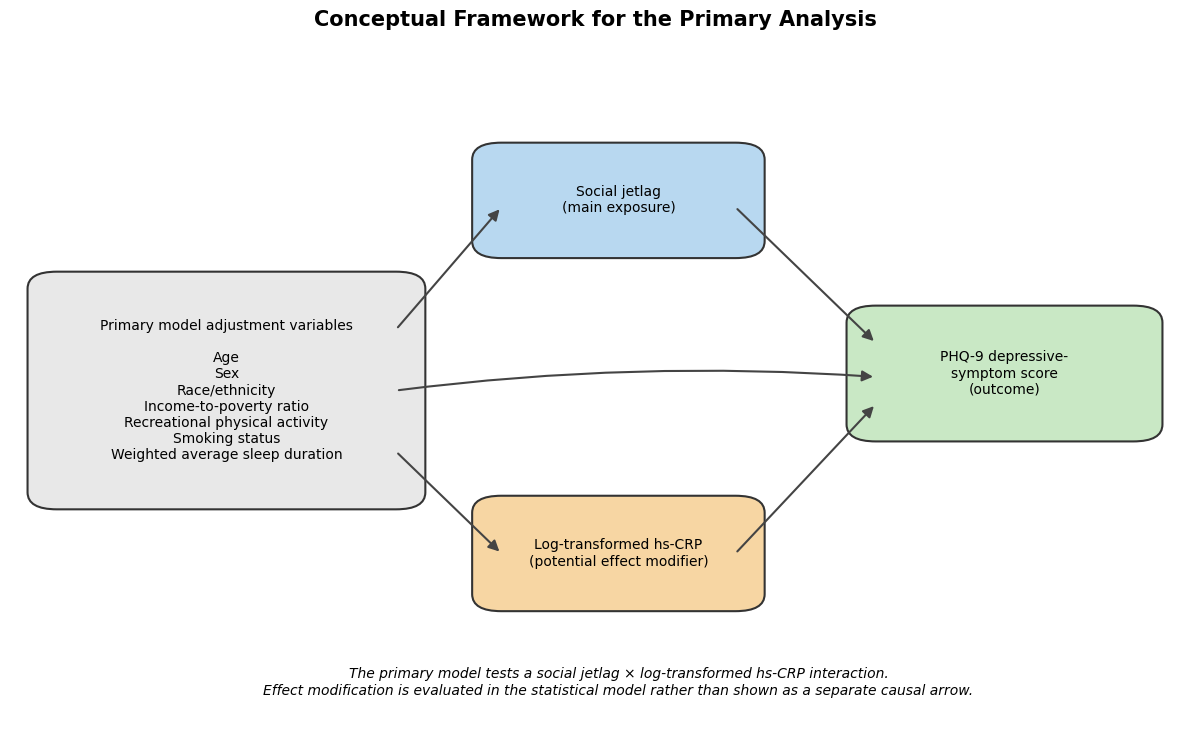

Figure saved to: /content/drive/MyDrive/reports/figures/conceptual_dag.png


In [21]:
# ============================================================
# FIGURE: CONCEPTUAL FRAMEWORK FOR THE PRIMARY ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path


# Create the figure-output folder using the project-relative path
# established in the environment setup cell.
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def add_node(ax, x, y, width, height, text, color):
    """Add a rounded rectangular node to the figure."""

    node = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.025",
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.5,
        zorder=2
    )

    ax.add_patch(node)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True,
        zorder=3
    )


def add_arrow(ax, start, end, curve=0.0):
    """Add a directed arrow between two nodes."""

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.5,
        color="#444444",
        connectionstyle=f"arc3,rad={curve}",
        zorder=4
    )

    ax.add_patch(arrow)


fig, ax = plt.subplots(figsize=(12, 7.5))


# ------------------------------------------------------------
# Add nodes
# ------------------------------------------------------------

add_node(
    ax,
    0.04, 0.35, 0.29, 0.30,
    "Primary model adjustment variables\n\n"
    "Age\n"
    "Sex\n"
    "Race/ethnicity\n"
    "Income-to-poverty ratio\n"
    "Recreational physical activity\n"
    "Smoking status\n"
    "Weighted average sleep duration",
    "#E8E8E8"
)

add_node(
    ax,
    0.42, 0.72, 0.20, 0.12,
    "Social jetlag\n(main exposure)",
    "#B8D8F0"
)

add_node(
    ax,
    0.42, 0.20, 0.20, 0.12,
    "Log-transformed hs-CRP\n(potential effect modifier)",
    "#F7D6A3"
)

add_node(
    ax,
    0.74, 0.45, 0.22, 0.15,
    "PHQ-9 depressive-\nsymptom score\n(outcome)",
    "#C9E8C5"
)


# ------------------------------------------------------------
# Add hypothesized relationships
# ------------------------------------------------------------

# Adjustment variables may relate to the exposure, effect
# modifier, and outcome.
add_arrow(ax, (0.33, 0.59), (0.42, 0.77))
add_arrow(ax, (0.33, 0.41), (0.42, 0.26))
add_arrow(ax, (0.33, 0.50), (0.74, 0.52), curve=-0.05)

# Primary relationships evaluated by the model.
add_arrow(ax, (0.62, 0.77), (0.74, 0.57))
add_arrow(ax, (0.62, 0.26), (0.74, 0.48))


# ------------------------------------------------------------
# Add interaction explanation
# ------------------------------------------------------------

ax.text(
    0.52,
    0.07,
    "The primary model tests a social jetlag × log-transformed hs-CRP interaction.\n"
    "Effect modification is evaluated in the statistical model rather than "
    "shown as a separate causal arrow.",
    ha="center",
    va="center",
    fontsize=10,
    style="italic",
    wrap=True
)


# ------------------------------------------------------------
# Format and save the figure
# ------------------------------------------------------------

ax.set_title(
    "Conceptual Framework for the Primary Analysis",
    fontsize=15,
    weight="bold",
    pad=18
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()

figure_path = FIGURE_DIR / "conceptual_dag.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Figure saved to:", figure_path)

## 15. Pipeline execution order and downstream handoff

Run the notebook from top to bottom in the following order:

1. Mount Google Drive and locate the shared `capstone_data` folder.
2. Define and load the eight required NHANES source files.
3. Select the required variables and merge the files by `SEQN`.
4. Restrict the starting analytic population to adults age 18 or older.
5. Create the PHQ-9 score, completeness flag, and depression indicator.
6. Clean HbA1c and hs-CRP and create log-transformed hs-CRP.
7. Calculate weekday and weekend sleep midpoints, social jetlag, and weighted average sleep duration.
8. Clean demographic, physical-activity, smoking, and BMI covariates.
9. Create complete-case eligibility flags for the primary and sensitivity models.
10. Generate sample-loss, missingness, and quality-control summaries.
11. Save the analysis-ready datasets and reporting tables to Google Drive.

### Final analysis datasets

- **Primary hs-CRP model:** 6,562 participants
- **HbA1c sensitivity model:** 6,741 participants
- **hs-CRP ≤ 10 mg/L sensitivity model:** 6,038 participants

### Final variable definitions

- **Outcome:** continuous PHQ-9 score
- **Primary exposure:** absolute social jetlag in hours
- **Primary biomarker:** log-transformed hs-CRP
- **Primary interaction:** social jetlag × log(hs-CRP)
- **Sensitivity biomarker:** HbA1c
- **Sleep-duration covariate:** weighted average of weekday and weekend sleep duration
- **Additional covariates:** age, sex, race/ethnicity, income-to-poverty ratio, recreational physical activity, and smoking status
- **Survey design variables:** `WTMECPRP`, `SDMVSTRA`, and `SDMVPSU`

### Data-quality decisions

- PHQ-9 scores require all nine questionnaire items.
- Invalid and nonresponse PHQ-9 values are recoded as missing.
- hs-CRP values above 10 mg/L are retained in the primary analysis and excluded only in a sensitivity analysis.
- Social jetlag is calculated as the absolute circular difference between weekend and weekday sleep midpoints.
- Complete-case flags are created separately for the hs-CRP and HbA1c models.
- Raw NHANES data and participant-level output files remain outside GitHub.

### Downstream notebook handoff

The remaining notebooks can use:

- `nhanes_cleaned.csv` for EDA and missingness analysis
- `nhanes_primary_hscrp_model.csv` for the primary statistical model
- `nhanes_hba1c_sensitivity_model.csv` for the HbA1c sensitivity model
- `nhanes_hscrp_le_10_sensitivity_model.csv` for the elevated hs-CRP sensitivity analysis
- The files under `capstone_outputs/tables/` for sample-loss, missingness, model-eligibility, and QC reporting
